<a href="https://colab.research.google.com/github/Andalejo1109/Gold-trading-bot-vs-long-term-investing/blob/main/Bot_1D_since_2022.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pandas_ta

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.3/240.3 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 69.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 107.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 16.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninst

In [1]:
import yfinance as yf
import pandas as pd
import pandas_ta as ta
import matplotlib.pyplot as plt
import numpy as np


Descargando datos de GC=F en temporalidad 1d desde 2022-01-01...


/tmp/ipykernel_2698/3984829518.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(TICKER, start=FECHA_INICIO, interval=INTERVALO, progress=False)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:147: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end_dt = pd.Timestamp.utcnow().tz_convert(tz)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


--------------------------------------------------
📊 RESULTADOS DESDE 2022-01-01 (1d)
--------------------------------------------------
Total de operaciones   : 47
Rendimiento Buy & Hold : 145.26%
Rendimiento de Bot     : 65.86%
Win Rate de la estrategia: 46.81%
--------------------------------------------------


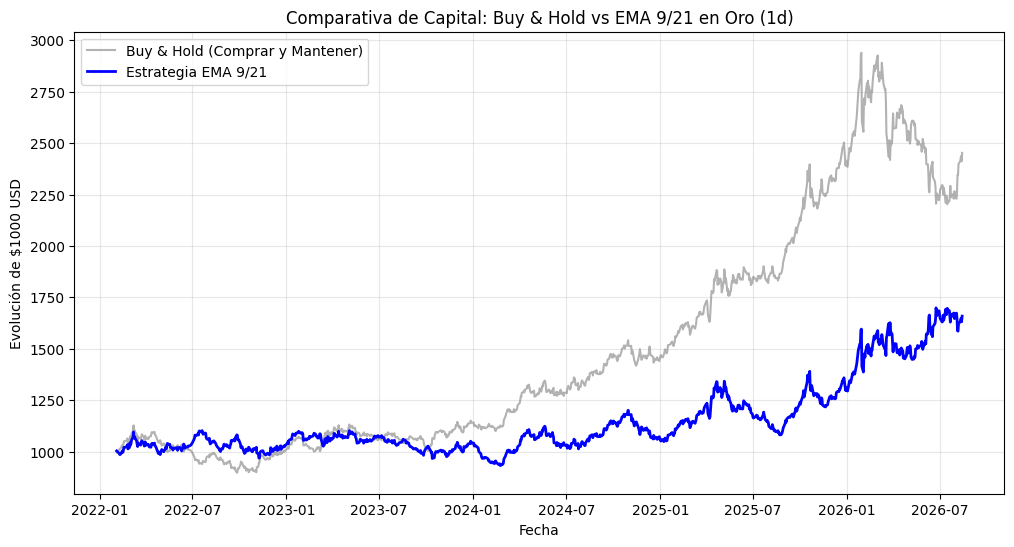

In [2]:

# ==========================================
# 1. PARÁMETROS DEL BACKTEST (LARGO PLAZO)
# ==========================================
TICKER = "GC=F"  # Futuros del Oro (XAU/USD)
FECHA_INICIO = "2022-01-01"
INTERVALO = "1d" # Temporalidad diaria
COSTO_TRANSACCION = 0.00015  # 0.015% de spread simulado por operación

print(f"Descargando datos de {TICKER} en temporalidad {INTERVALO} desde {FECHA_INICIO}...")
df = yf.download(TICKER, start=FECHA_INICIO, interval=INTERVALO, progress=False)

if df.empty:
    print("Error descargando datos. Verifica tu conexión o el ticker.")
    quit()

# Aplanar columnas si yfinance devuelve un formato MultiIndex
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# ==========================================
# 2. CÁLCULO DE INDICADORES (EMA 9 y 21)
# ==========================================
df.ta.ema(close='Close', length=9, append=True)
df.ta.ema(close='Close', length=21, append=True)
df.rename(columns={'EMA_9': 'ema_9', 'EMA_21': 'ema_21'}, inplace=True)
df.dropna(inplace=True)

# ==========================================
# 3. LÓGICA VECTORIZADA
# ==========================================
# Señal: 1 (Largo) si EMA9 > EMA21, de lo contrario -1 (Corto)
df['signal'] = np.where(df['ema_9'] > df['ema_21'], 1, -1)

# Operamos al cierre/apertura del día siguiente al cruce
df['position'] = df['signal'].shift(1)
df.dropna(inplace=True)

# ==========================================
# 4. RENDIMIENTOS Y COSTOS
# ==========================================
df['returns_bh'] = df['Close'].pct_change()
df['returns_strategy'] = df['returns_bh'] * df['position']

# Identificar los días donde hubo un cambio de posición (trade)
df['trade'] = df['position'].diff().abs() > 0
# Restar el costo de spread cada vez que se ejecuta una orden
df.loc[df['trade'], 'returns_strategy'] -= COSTO_TRANSACCION

# Capitalizar retornos asumiendo $1000 iniciales
df['equity_bh'] = (1 + df['returns_bh']).cumprod() * 1000
df['equity_strategy'] = (1 + df['returns_strategy']).cumprod() * 1000

# ==========================================
# 5. MÉTRICAS FINALES
# ==========================================
total_trades = df['trade'].sum()
rendimiento_bh = (df['equity_bh'].iloc[-1] / 1000 - 1) * 100
rendimiento_estrategia = (df['equity_strategy'].iloc[-1] / 1000 - 1) * 100
win_rate = (df.loc[df['trade'], 'returns_strategy'] > 0).mean() * 100

print("-" * 50)
print(f"📊 RESULTADOS DESDE {FECHA_INICIO} ({INTERVALO})")
print("-" * 50)
print(f"Total de operaciones   : {total_trades}")
print(f"Rendimiento Buy & Hold : {rendimiento_bh:.2f}%")
print(f"Rendimiento de Bot     : {rendimiento_estrategia:.2f}%")
print(f"Win Rate de la estrategia: {win_rate:.2f}%")
print("-" * 50)

# ==========================================
# 6. VISUALIZACIÓN
# ==========================================
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['equity_bh'], label='Buy & Hold (Comprar y Mantener)', color='gray', alpha=0.6, linewidth=1.5)
plt.plot(df.index, df['equity_strategy'], label='Estrategia EMA 9/21', color='blue', linewidth=2)
plt.title(f'Comparativa de Capital: Buy & Hold vs EMA 9/21 en Oro ({INTERVALO})')
plt.ylabel('Evolución de $1000 USD')
plt.xlabel('Fecha')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()